In [2]:
%matplotlib inline
from IPython.display import display, Markdown
from datetime import time, datetime, date, timedelta
import snakemd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as dates

import fitfile
from garmindb import GarminConnectConfigManager
from garmindb.garmindb import GarminDb, Attributes, ActivitiesDb, Activities, StepsActivities, ActivityLaps, ActivityRecords
from idbutils.list_and_dict import list_not_none

from jupyter_funcs import format_number

gc_config = GarminConnectConfigManager()
db_params_dict = gc_config.get_db_params()

garmin_db = GarminDb(db_params_dict)
garmin_act_db = ActivitiesDb(db_params_dict)
measurement_system = Attributes.measurements_type(garmin_db)
unit_strings = fitfile.units.unit_strings[measurement_system]
distance_units = {"miles": "m"}[unit_strings[fitfile.units.UnitTypes.distance_long]]

def __format_activity(activity):
    if activity:
        if activity.is_steps_activity():
            steps_activity = StepsActivities.get(garmin_act_db, activity.activity_id)
#             return [activity.activity_id, activity.name, activity.start_time.strftime("%y%m%d"), activity.sport, format_number(activity.distance, 1), activity.elapsed_time, format_number(activity.avg_speed, 1), steps_activity.avg_pace, format_number(activity.calories)]
            return [activity.activity_id, activity.name, activity.start_time.strftime("%y%m%d"), activity.sport, format_number(activity.distance, 1), activity.elapsed_time, activity.moving_time, format_number(activity.avg_speed, 1), format_number(activity.calories)]
        return [activity.activity_id, activity.name, activity.start_time.strftime("%y%m%d"), activity.sport, format_number(activity.distance, 1), activity.elapsed_time, activity.moving_time, format_number(activity.avg_speed, 1), format_number(activity.calories)]
    return ['', '', '', '', '', '', '', '', '']


activities = Activities.get_latest(garmin_act_db, Activities.row_count(garmin_act_db))

In [8]:
def debug(name=None):
    doc = snakemd.new_doc()
    if (name is None):
        rows = [__format_activity(activity) for activity in activities]
    else:
        rows = [__format_activity(activity) for activity in activities if ((activity.name is not None) and (name in activity.name.lower()))]
    doc.add_heading("All Recorded Activities", 3)
    doc.add_table(['Id', 'Name', 'Date', 'Sport', f'Dist ({distance_units})', 'Elapsed Time', f'Moving Time', f'Speed ({unit_strings[fitfile.units.UnitTypes.speed]})', 'Calories'], rows)
    display(Markdown(str(doc)))

debug()

### All Recorded Activities

| Id          | Name                      | Date   | Sport             | Dist (m) | Elapsed Time    | Moving Time     | Speed (mph) | Calories |
| ----------- | ------------------------- | ------ | ----------------- | -------- | --------------- | --------------- | ----------- | -------- |
| 19449558462 | Bloomfield - Base         | 250616 | running           | 4.3      | 00:38:56.297000 | 00:38:56.297000 | 6.7         | 582      |
| 19406008016 | Ann Arbor Running         | 250611 | running           | 3.7      | 00:34:54.354000 | 00:34:52.220000 | 6.4         | 503      |
| 19325595537 | Ann Arbor - Base          | 250603 | running           | 3.4      | 00:30:50.804000 | 00:30:50.804000 | 6.7         | 454      |
| 19022041208 | Ann Arbor Running         | 250504 | running           | 3.6      | 00:31:52.386000 | 00:31:47.439000 | 6.7         | 467      |
| 18815720483 | Bloomfield - Base         | 250413 | running           | 1.2      | 00:10:36.540000 | 00:10:35.897000 | 6.9         | 140      |
| 18810840532 | Ann Arbor - Base          | 250412 | running           | 3.6      | 00:32:39.094000 | 00:32:39.094000 | 6.7         | 463      |
| 18773048182 | Ann Arbor - Base          | 250408 | running           | 3.6      | 00:35:10.970000 | 00:35:10.970000 | 6.2         | 476      |
| 18704544726 | Ann Arbor - Base          | 250401 | running           | 3.7      | 00:32:15.717000 | 00:32:15.717000 | 6.9         | 461      |
| 18684852340 | Ann Arbor - Base          | 250330 | running           | 3.1      | 00:27:51.361000 | 00:27:32.920000 | 6.8         | 407      |
| 18427612758 | Miami Running             | 250303 | running           | 4.7      | 00:41:06.315000 | 00:41:06.315000 | 6.9         | 651      |
| 18333114726 | Ann Arbor - Base          | 250220 | running           | 0.5      | 00:51:06.621000 | 00:51:06.621000 | 0.6         | 684      |
| 18309980343 | Base                      | 250218 | running           | 3.8      | 00:38:04.547000 | 00:38:00.496000 | 5.9         | 451      |
| 18294358443 | Base                      | 250216 | running           | 4.1      | 00:53:10.453000 | 00:53:10.453000 | 4.6         | 570      |
| 18286900134 | Treadmill Running         | 250215 | running           | 2.7      | 00:45:55.169000 | 00:45:04.155000 | 3.6         | 454      |
| 18274608462 | Base                      | 250214 | running           | 2.7      | 00:28:19.741000 | 00:28:19.741000 | 5.7         | 371      |
| 18248197626 | Base                      | 250211 | running           | 2.7      | 00:28:59.702000 | 00:28:59.702000 | 5.6         | 377      |
| 18141389132 | Base                      | 250130 | running           | 4.1      | 00:40:05.990000 | 00:40:05.990000 | 6.2         | 514      |
| 18128937527 | Threshold                 | 250128 | running           | 3.4      | 00:34:06.415000 | 00:34:06.415000 | 6.0         | 490      |
| 18106837246 | Base                      | 250126 | running           | 4.1      | 00:40:05.427000 | 00:40:05.427000 | 6.2         | 512      |
| 18101282981 | Recovery                  | 250125 | running           | 2.0      | 00:21:50.514000 | 00:21:50.514000 | 5.6         | 278      |
| 18088926253 | Recovery                  | 250124 | running           | 2.0      | 00:20:08.569000 | 00:20:08.569000 | 6.1         | 256      |
| 18085266793 | Base                      | 250123 | running           | 4.0      | 00:40:05.448000 | 00:40:05.448000 | 5.9         | 504      |
| 18067574743 | Base                      | 250121 | running           | 2.7      | 00:27:03.135000 | 00:27:03.135000 | 6.0         | 370      |
| 18046209314 | Base                      | 250119 | running           | 3.8      | 00:40:03.539000 | 00:40:03.539000 | 5.7         | 539      |
| 18039771818 | Base                      | 250118 | running           | 2.6      | 00:27:03.630000 | 00:27:03.630000 | 5.7         | 376      |
| 18031048755 | Base                      | 250117 | running           | 2.6      | 00:27:08.030000 | 00:27:08.030000 | 5.7         | 368      |
| 18014695288 | Treadmill Running         | 250115 | running           | 4.0      | 00:40:15.986000 | 00:40:15.986000 | 6.0         | 572      |
| 17674967439 | Treadmill Running         | 241202 | running           | 4.5      | 00:40:00.472000 | 00:40:00.472000 | 6.7         | 544      |
| 17659484422 | Benchmark Run             | 241130 | running           | 5.0      | 00:39:38.512000 | 00:39:09.095000 | 7.7         | 507      |
| 17622888796 | Treadmill Running         | 241125 | running           | 5.0      | 00:50:00.736000 | 00:50:00.736000 | 6.0         | 644      |
| 17607268207 | Ann Arbor - Easy Run      | 241123 | running           | 1.4      | 00:35:09.715000 | 00:35:08.304000 | 2.4         | 413      |
| 17600745185 | Goal Pace Run             | 241122 | running           | 3.9      | 00:35:25.853000 | 00:35:16.999000 | 6.6         | 482      |
| 17575258834 | Treadmill Running         | 241118 | running           | 4.3      | 15:36:02.372000 | 15:36:02.372000 | 0.3         | 643      |
| 17524741804 | Treadmill Running         | 241112 | running           | 4.6      | 01:02:21.791000 | 01:02:21.791000 | 4.4         | 680      |
| 17499842709 | Easy Run                  | 241109 | running           | 2.1      | 00:22:01.266000 | 00:22:01.266000 | 5.8         | 294      |
| 17499726852 | Strength                  | 241109 | fitness_equipment | 0.0      | 00:41:30.236000 | 00:41:30.236000 | 0.0         | 304      |
| 17476064931 | Strength                  | 241106 | fitness_equipment | 0.0      | 01:04:08.845000 | 01:04:08.845000 | 0.0         | 407      |
| 17467973338 | Treadmill Running         | 241105 | running           | 4.1      | 00:40:05.265000 | 00:40:05.265000 | 6.1         | 538      |
| 17467743887 | Strength                  | 241105 | fitness_equipment | 0.0      | 00:46:46.761000 | 00:46:46.761000 | 0.0         | 279      |
| 17459787961 | Strength                  | 241104 | fitness_equipment | 0.0      | 00:50:07.562000 | 00:50:07.562000 | 0.0         | 366      |
| 17449497518 | Easy Run                  | 241103 | running           | 3.3      | 00:36:39.757000 | 00:36:38.977000 | 5.5         | 474      |
| 17431398734 | Treadmill Running         | 241101 | running           | 3.2      | 00:42:01.536000 | 00:42:01.536000 | 4.6         | 521      |
| 17406754529 | Treadmill Running         | 241029 | running           | 5.0      | 00:50:02.335000 | 00:50:02.335000 | 6.0         | 679      |
| 17392527660 | Treadmill Running         | 241027 | running           | 10.7     | 01:50:34.708000 | 01:50:34.003000 | 5.8         | 1456     |
| 17384862884 | Ann Arbor - Easy Run      | 241026 | running           | 2.8      | 00:30:46.154000 | 00:30:46.154000 | 5.5         | 478      |
| 17361166859 | Strength                  | 241023 | fitness_equipment | 0.0      | 00:46:49.730000 | 00:46:49.730000 | 0.0         | 314      |
| 17353241336 | Strength                  | 241022 | fitness_equipment | 0.0      | 00:40:47.182000 | 00:40:47.182000 | 0.0         | 300      |
| 17344073562 | Strength                  | 241021 | fitness_equipment | 0.0      | 00:40:04.407000 | 00:40:04.407000 | 0.0         | 246      |
| 17333976949 | Long Easy Run             | 241020 | running           | 10.4     | 01:45:08.946000 | 01:45:04.026000 | 5.9         | 1417     |
| 17319274154 | Strength                  | 241018 | fitness_equipment | 0.0      | 00:47:32.711000 | 00:47:32.711000 | 0.0         | 303      |
| 17315531099 | Treadmill Running         | 241018 | running           | 4.1      | 00:47:48.703000 | 00:47:48.703000 | 5.2         | 535      |
| 17308198203 | Goal Pace Run             | 241017 | running           | 5.1      | 00:50:00        | 00:50:00        | 6.1         | 666      |
| 17299640288 | Ann Arbor Running         | 241016 | running           | 3.0      | 00:41:52.257000 | 00:41:52.257000 | 4.3         | 592      |
| 17200622894 | Ann Arbor - Easy Run      | 241004 | running           | 4.5      | 00:43:23.449000 | 00:42:53.701000 | 6.3         | 593      |
| 17193104109 | Ann Arbor - Easy Run      | 241003 | running           | 3.7      | 00:34:49.330000 | 00:34:46.155000 | 6.4         | 482      |
| 17176025316 | Ann Arbor - Benchmark Run | 241001 | running           | 2.7      | 00:27:54.835000 | 00:24:22.482000 | 6.6         | 379      |
| 17161413828 | Ann Arbor Running         | 240929 | running           | 6.3      | 00:58:53.145000 | 00:58:46.723000 | 6.5         | 1076     |

In [9]:
import numpy as np

def __plot_activity(name:str, ydata:str, cdata:str, ylimdata = None, yticksdata:tuple[float, float] = None):
    start_dates = []
    moving_times = []
    moving_times_min = []
    distances = []
    calories = []
    time100m = []
    time1000m = []
    speed = []
    for activity in activities:
        if ((activity.name is not None) and (name in activity.name.lower())):
            s = activity.distance
            t = (datetime.combine(date.min, activity.moving_time) - datetime.min).total_seconds()
            if (s > 0):
                time100m += [t/s/10]
                time1000m += [t/s]
            else:
                time100m += [0]
                time1000m += [0]
            start_dates += [activity.start_time]
            moving_times += [t]
            moving_times_min += [t/60]
            calories += [activity.calories]
            distances += [s]
            speed += [activity.avg_speed]

    yarray = []
    carray = []
    match ydata:
        case "moving_time": yarray = moving_times
        case "moving_time_min": yarray = moving_times_min
        case "calorie": yarray = calories
        case "distance": yarray = distances
        case "time100m": yarray = time100m
        case "time1000m": yarray = time1000m
        case "speed": yarray = speed
    match cdata:
        case "moving_time": carray = moving_times
        case "moving_time_min": carray = moving_times_min
        case "calorie": carray = calories
        case "distance": carray = distances
        case "time100m": carray = time100m
        case "time1000m": carray = time1000m
        case "speed": carray = speed

    #debug(name)
    #display(Markdown(str(start_dates)))
    #display(Markdown(str(yarray)))

    fig = plt.figure(figsize=(20,5), dpi= 100, facecolor='w', edgecolor='k')
    plt.scatter(start_dates, yarray, c=carray, norm=matplotlib.colors.LogNorm(), cmap="rainbow")

    x_num = dates.date2num(start_dates)
    trend = np.polyfit(x_num, yarray, 3)
    fit = np.poly1d(trend)
    x_fit = np.linspace(x_num.min(), x_num.max())
    plt.plot(dates.num2date(x_fit), fit(x_fit), "r--")

    ax = plt.gca()
    plt.grid(visible=True, which='major', color='#666666', linestyle='-')
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2)
    years = plt.matplotlib.dates.YearLocator()
    months = plt.matplotlib.dates.MonthLocator()
    # yearsFmt = plt.matplotlib.dates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_minor_locator(months)
    # ax.xaxis.set_major_formatter(yearsFmt)

    plt.title(f"{name} sessions: {len(rows)}")
    plt.colorbar(label=cdata)
    plt.ylabel(ydata)
    if ylimdata is not None:
        plt.ylim(ylimdata)
    if yticksdata is not None:
        plt.yticks(yticksdata)
    plt.show()


NameError: name 'rows' is not defined

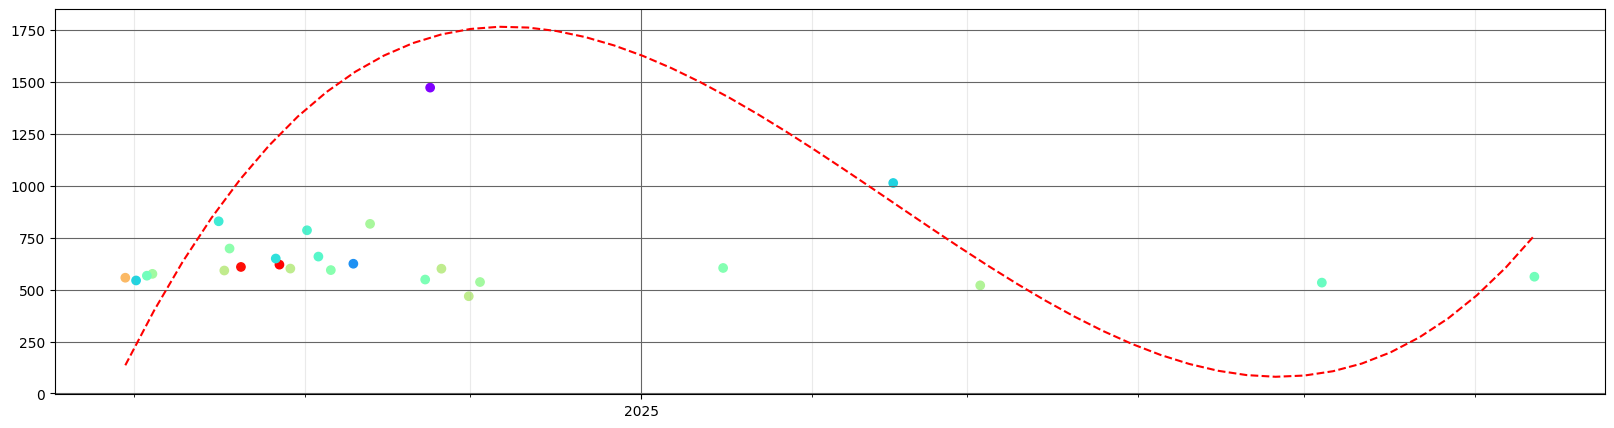

In [10]:
# __plot_activity("swim", "time100m", "distance")
# __plot_activity("swim", "time100m", "calorie")
# __plot_activity("swim", "speed", "calorie")
__plot_activity("run", "time1000m", "distance", yticksdata=[300, 360, 420, 480], ylimdata=[300, 480])
__plot_activity("run", "time1000m", "calorie", yticksdata=[300, 360, 420, 480], ylimdata=[300, 480])
__plot_activity("run", "speed", "calorie")

/tmp/ipykernel_3035813/1617114887.py:47: RankWarning: Polyfit may be poorly conditioned
  trend = np.polyfit(x_num, time1000m, 7)


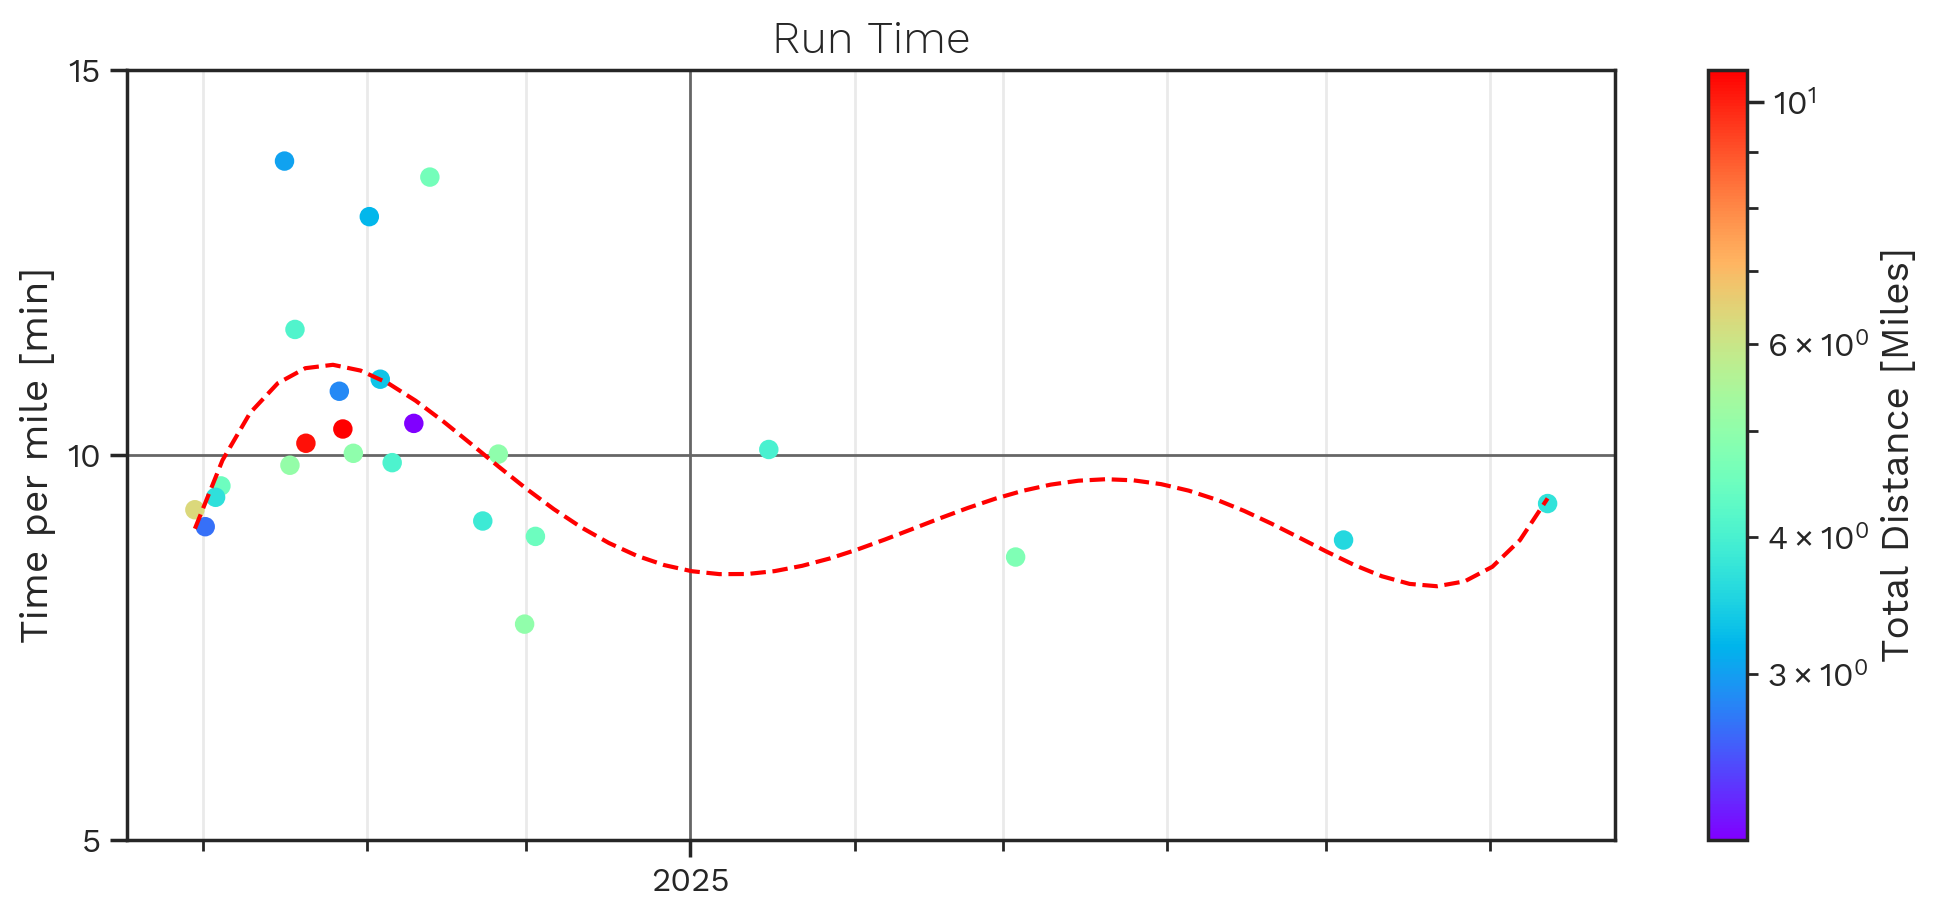

In [ ]:
# Running
import seaborn as sns


def set_style():
    sns.set_context("poster", font_scale=1.5)
    rc = {
        "font.family": "sans-serif",
        "font.sans-serif": "Work Sans",
        # "axes.spines.top": False,
        # "axes.spines.right": False,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "axes.titleweight": 300,
        "axes.labelweight": 400,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 300,
        "savefig.bbox": "tight",
    }
    palette = sns.color_palette("ch:start=.2,rot=-.3")
    sns.set_theme(palette=palette, rc=rc, style="ticks")
    return palette

start_dates = []
moving_times = []
distances = []
time1000m = []
for activity in activities:
    if ((activity.name is not None) and ("run" in activity.name.lower())):
        s = activity.distance
        t = (datetime.combine(date.min, activity.moving_time) - datetime.min).total_seconds() / 60
        
        if (5 < t/s < 15) and (s > 0.5):
            time1000m += [t/s]
            start_dates += [activity.start_time]
            moving_times += [t]
            distances += [s]

palette = set_style()
colormap = sns.color_palette(palette, as_cmap=True)

fig = plt.figure(figsize=(12,5), dpi= 200, facecolor='w', edgecolor='k')
plt.scatter(start_dates, time1000m, c=distances, norm=matplotlib.colors.LogNorm(), cmap=colormap)

x_num = dates.date2num(start_dates)
trend = np.polyfit(x_num, time1000m, 7)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "r--")

ax = plt.gca()
plt.grid(visible=True, which='major', linestyle='-')
plt.grid(visible=True, which='minor', linestyle='-', alpha=0.2)
years = plt.matplotlib.dates.YearLocator()
months = plt.matplotlib.dates.MonthLocator()
# yearsFmt = plt.matplotlib.dates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_minor_locator(months)
# ax.xaxis.set_major_formatter(yearsFmt)

plt.title("Run Time")
plt.colorbar(label="Total Distance [Miles]")
plt.ylabel("Time per mile [min]")
plt.ylim(5, 15)
plt.yticks([5, 10, 15])
plt.show()

/tmp/ipykernel_3035813/1544328043.py:76: RankWarning: Polyfit may be poorly conditioned
  trend = np.polyfit(x_num, hrs, 7)
/tmp/ipykernel_3035813/1544328043.py:76: RankWarning: Polyfit may be poorly conditioned
  trend = np.polyfit(x_num, hrs, 7)


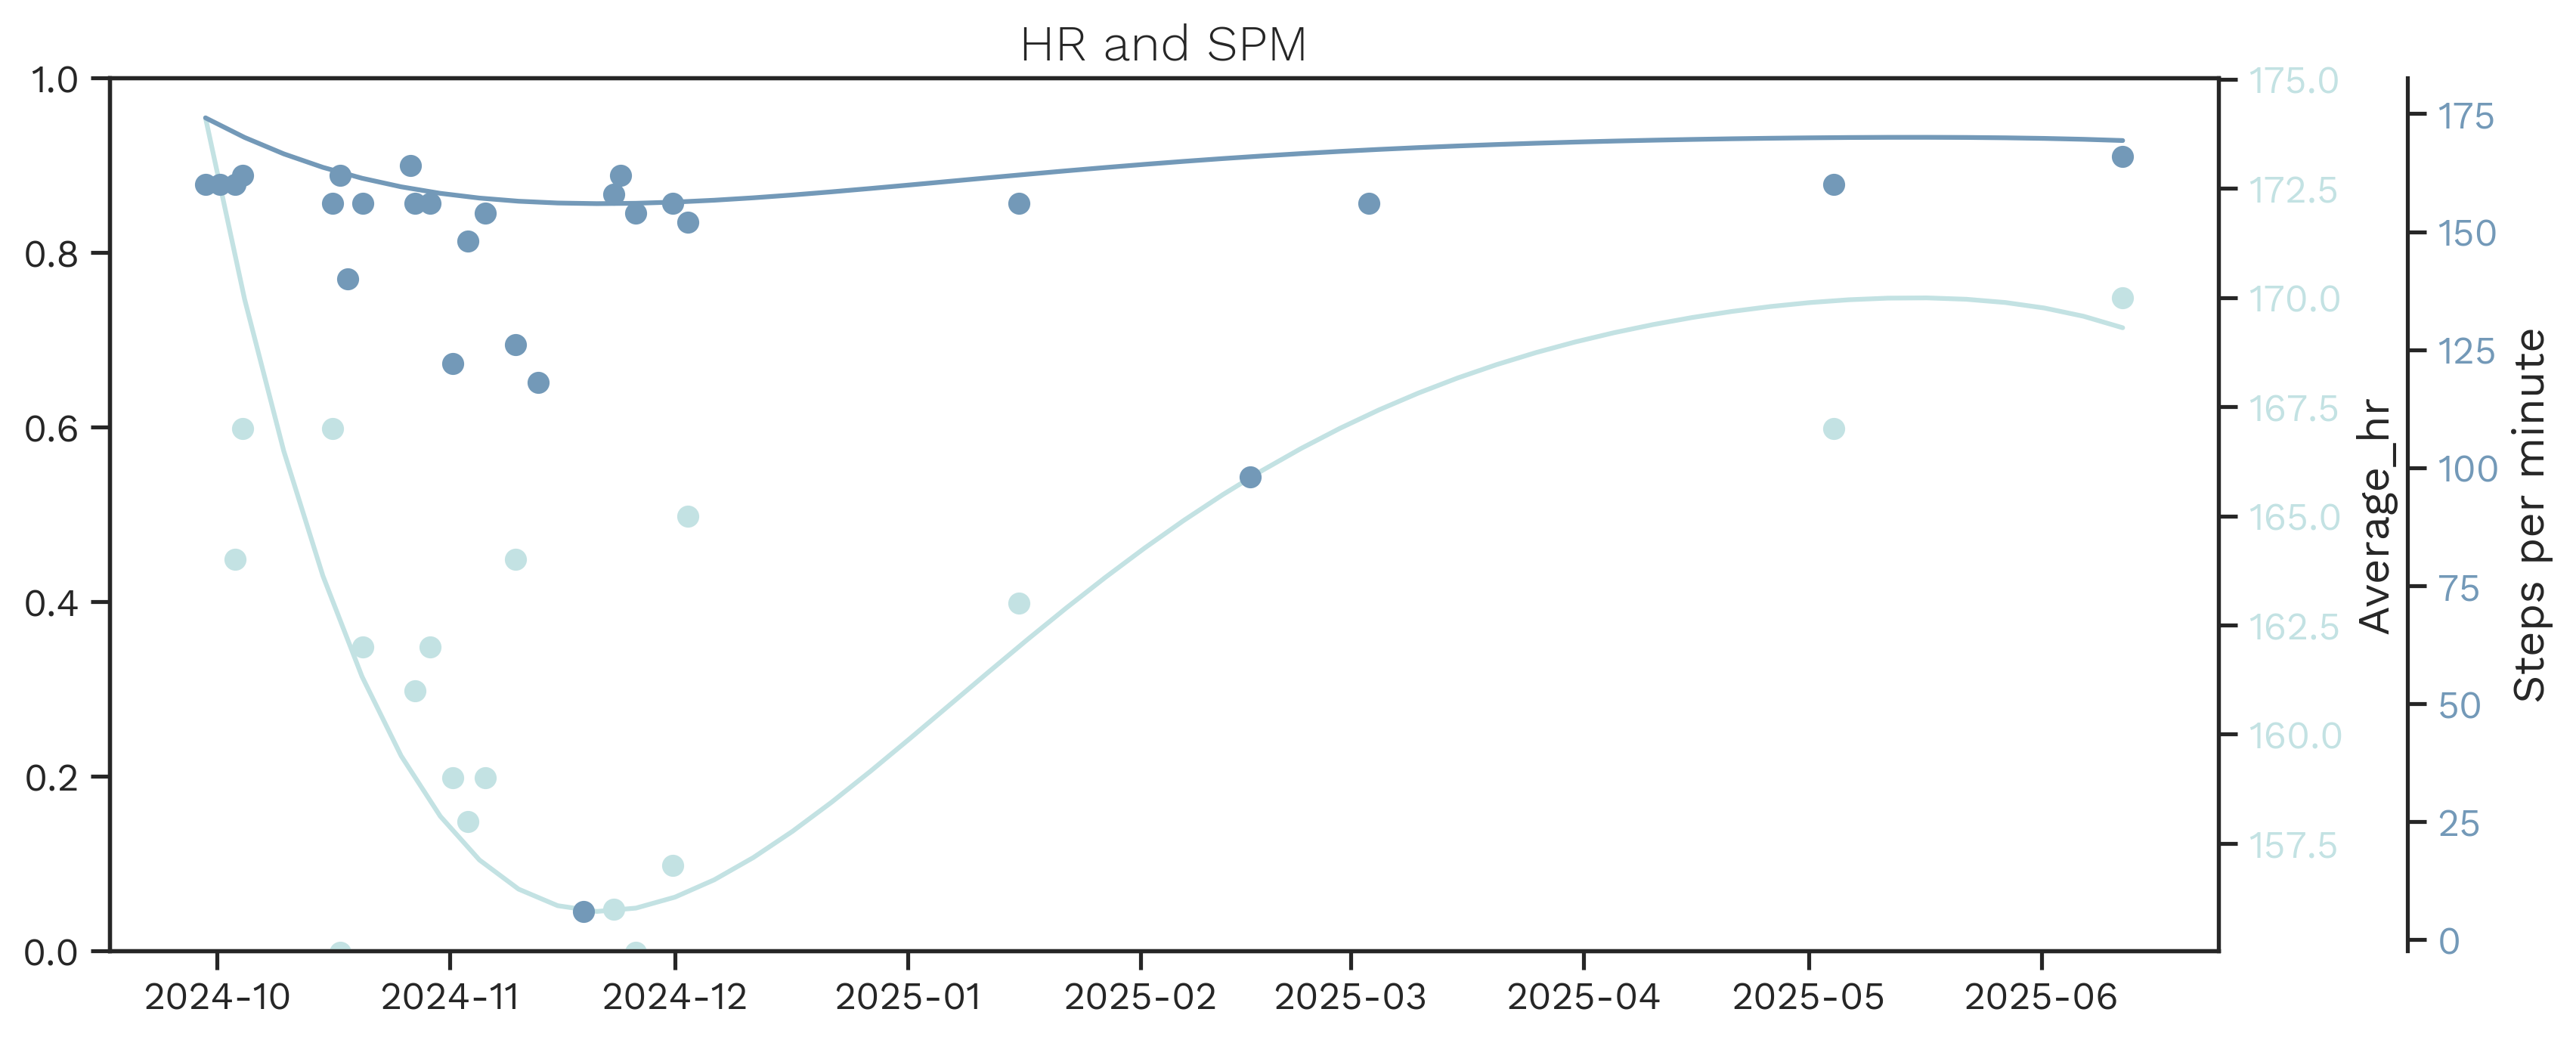

In [ ]:
# Running
import seaborn as sns


def set_style():
    sns.set_context("poster", font_scale=1.5)
    rc = {
        "font.family": "sans-serif",
        "font.sans-serif": "Work Sans",
        # "axes.spines.top": False,
        # "axes.spines.right": False,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "axes.titleweight": 300,
        "axes.labelweight": 400,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 300,
        "savefig.bbox": "tight",
    }
    palette = sns.color_palette("ch:start=.2,rot=-.3")
    sns.set_theme(palette=palette, rc=rc, style="ticks")
    return palette

start_dates = []
moving_times = []
spm = []
hrs = []
for activity in activities:
    if ((activity.name is not None) and ("run" in activity.name.lower())):
        avg_hr = activity.avg_hr
        cadence = activity.avg_cadence
        
        hrs += [avg_hr]
        spm += [cadence*2]
        start_dates += [activity.start_time]
        moving_times += [t]
        distances += [s]

fig, host = plt.subplots(figsize=(12,5))


palette = set_style()

columns = { "avg_hr" : 
                   %matplotlib inline
from IPython.display import display, Markdown
from datetime import time, datetime, date, timedelta
import snakemd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as dates

import fitfile
from garmindb import GarminConnectConfigManager
from garmindb.garmindb import GarminDb, Attributes, ActivitiesDb, Activities, StepsActivities, ActivityLaps, ActivityRecords
from idbutils.list_and_dict import list_not_none

from jupyter_funcs import format_number

gc_config = GarminConnectConfigManager()
db_params_dict = gc_config.get_db_params()

garmin_db = GarminDb(db_params_dict)
garmin_act_db = ActivitiesDb(db_params_dict)
measurement_system = Attributes.measurements_type(garmin_db)
unit_strings = fitfile.units.unit_strings[measurement_system]
distance_units = {"miles": "m"}[unit_strings[fitfile.units.UnitTypes.distance_long]]

def __format_activity(activity):
    if activity:
        if activity.is_steps_activity():
            steps_activity = StepsActivities.get(garmin_act_db, activity.activity_id)
#             return [activity.activity_id, activity.name, activity.start_time.strftime("%y%m%d"), activity.sport, format_number(activity.distance, 1), activity.elapsed_time, format_number(activity.avg_speed, 1), steps_activity.avg_pace, format_number(activity.calories)]
            return [activity.activity_id, activity.name, activity.start_time.strftime("%y%m%d"), activity.sport, format_number(activity.distance, 1), activity.elapsed_time, activity.moving_time, format_number(activity.avg_speed, 1), format_number(activity.calories)]
        return [activity.activity_id, activity.name, activity.start_time.strftime("%y%m%d"), activity.sport, format_number(activity.distance, 1), activity.elapsed_time, activity.moving_time, format_number(activity.avg_speed, 1), format_number(activity.calories)]
    return ['', '', '', '', '', '', '', '', '']


activities = Activities.get_latest(garmin_act_db, Activities.row_count(garmin_act_db)){
                       "label": "Average_hr",
                       "trend_marker": "--",
                       "color": palette[0],
                       "data": hrs
                   }, 
            "spm": 
                   {
                       "label": "Steps per minute",
                       "trend_marker": "--",
                       "color": palette[2],
                       "data": spm
                   },
}

plots = []
step = 0


for col in columns:
   
    ax2 = host.twinx()
    ax2.set_ylabel(columns[col]["label"])
    ax2.tick_params(axis='y', labelcolor=columns[col]["color"])

    plot = ax2.scatter(start_dates, columns[col]["data"], color=columns[col]["color"], label=columns[col]["label"])

    fit_label = "Fit " + columns[col]["label"]
    x_num = dates.date2num(start_dates)
    trend = np.polyfit(x_num, hrs, 7)
    fit = np.poly1d(trend)
    x_fit = np.linspace(x_num.min(), x_num.max())
    fit = ax2.plot(dates.num2date(x_fit), fit(x_fit), color=columns[col]["color"], label=fit_label)

    # data
    plots.append(plot)
    plots.append(fit)
    
    ax2.spines['right'].set_position(('outward', step))
    
    step = step + 60
    

# ax = plt.gca()
# plt.grid(visible=True, which='major', color='#666666', linestyle='-')
# plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2)
# years = plt.matplotlib.dates.YearLocator()
# months = plt.matplotlib.dates.MonthLocator()
# # yearsFmt = plt.matplotlib.dates.DateFormatter('%Y')
# ax.xaxis.set_major_locator(years)
# ax.xaxis.set_minor_locator(months)
# # ax.xaxis.set_major_formatter(yearsFmt)

plt.title("HR and SPM")
# plt.ylabel("Average HR")
# plt.ylim(100, 200)
# plt.yticks([100, 125, 150, 175, 200])
plt.show()

[datetime.datetime(2025, 2, 1, 13, 27, 33), datetime.datetime(2025, 1, 31, 12, 7, 21), datetime.datetime(2025, 1, 28, 21, 31, 3), datetime.datetime(2025, 1, 24, 8, 20, 4), datetime.datetime(2025, 1, 18, 7, 56, 48), datetime.datetime(2025, 1, 18, 7, 24, 23), datetime.datetime(2025, 1, 17, 13, 2, 48), datetime.datetime(2025, 1, 14, 21, 4, 43), datetime.datetime(2025, 1, 11, 8, 2, 33), datetime.datetime(2025, 1, 5, 7, 44, 38), datetime.datetime(2025, 1, 2, 15, 55, 38), datetime.datetime(2024, 12, 31, 20, 17, 53), datetime.datetime(2024, 12, 27, 12, 6, 51), datetime.datetime(2024, 12, 21, 8, 5, 10), datetime.datetime(2024, 12, 15, 14, 19, 58), datetime.datetime(2024, 12, 14, 13, 37, 14), datetime.datetime(2024, 12, 10, 21, 55, 58), datetime.datetime(2024, 12, 5, 21, 57, 57), datetime.datetime(2024, 11, 27, 9, 13), datetime.datetime(2024, 11, 14, 8, 6, 23), datetime.datetime(2024, 11, 11, 21, 32, 45), datetime.datetime(2024, 11, 9, 15, 42, 35), datetime.datetime(2024, 11, 9, 14, 56, 28), datetime.datetime(2024, 11, 7, 22, 25, 54), datetime.datetime(2024, 11, 7, 8, 17, 25), datetime.datetime(2024, 11, 5, 22, 12), datetime.datetime(2024, 11, 5, 14, 15, 1), datetime.datetime(2024, 11, 3, 20, 13, 27), datetime.datetime(2024, 11, 2, 15, 4, 21), datetime.datetime(2024, 11, 2, 13, 1, 7), datetime.datetime(2024, 10, 26, 16, 18, 42), datetime.datetime(2024, 10, 26, 15, 15, 46), datetime.datetime(2024, 10, 22, 12, 34, 53), datetime.datetime(2024, 10, 17, 21, 49, 25), datetime.datetime(2024, 10, 12, 11, 43, 52), datetime.datetime(2024, 10, 7, 11, 51, 42), datetime.datetime(2024, 10, 3, 18, 5, 57), datetime.datetime(2024, 9, 24, 13, 45, 38), datetime.datetime(2024, 9, 16, 17, 41, 21), datetime.datetime(2024, 9, 9, 10, 15), datetime.datetime(2024, 9, 8, 16, 27, 54), datetime.datetime(2024, 9, 7, 16, 32, 43), datetime.datetime(2024, 9, 1, 15, 50, 14), datetime.datetime(2024, 8, 22, 21, 23, 52), datetime.datetime(2024, 7, 25, 21, 58, 7), datetime.datetime(2024, 7, 21, 15, 22, 59), datetime.datetime(2024, 7, 19, 22, 31, 55), datetime.datetime(2024, 7, 9, 12, 39, 6), datetime.datetime(2024, 6, 12, 21, 38, 17), datetime.datetime(2024, 6, 2, 23, 15), datetime.datetime(2024, 5, 29, 22, 10, 52), datetime.datetime(2024, 5, 29, 21, 40, 57), datetime.datetime(2024, 5, 28, 22, 48, 40), datetime.datetime(2024, 5, 25, 15, 56, 11), datetime.datetime(2024, 5, 12, 11, 0, 31), datetime.datetime(2024, 5, 9, 21, 27, 16), datetime.datetime(2024, 5, 7, 22, 48, 55), datetime.datetime(2024, 4, 23, 21, 54, 17), datetime.datetime(2024, 4, 21, 8, 45, 21), datetime.datetime(2024, 4, 18, 21, 38, 36), datetime.datetime(2024, 4, 17, 23, 18, 26), datetime.datetime(2024, 3, 25, 21, 20), datetime.datetime(2024, 3, 23, 10, 47, 36), datetime.datetime(2024, 3, 21, 22, 59, 33), datetime.datetime(2024, 3, 20, 21, 54, 48), datetime.datetime(2024, 2, 28, 9, 49, 32), datetime.datetime(2024, 2, 23, 9, 7, 8), datetime.datetime(2024, 2, 21, 9, 13, 48), datetime.datetime(2024, 2, 20, 15, 55, 24), datetime.datetime(2024, 2, 19, 8, 12, 50), datetime.datetime(2024, 2, 17, 11, 24, 36), datetime.datetime(2024, 2, 11, 15, 45, 53), datetime.datetime(2024, 2, 4, 9, 18, 19), datetime.datetime(2024, 1, 29, 14, 29, 43), datetime.datetime(2024, 1, 27, 14, 33, 41), datetime.datetime(2024, 1, 25, 14, 11, 12), datetime.datetime(2024, 1, 20, 14, 11, 38), datetime.datetime(2024, 1, 17, 13, 51, 8), datetime.datetime(2024, 1, 8, 15, 11, 9), datetime.datetime(2023, 12, 29, 14, 32, 20), datetime.datetime(2023, 12, 14, 16, 8, 13), datetime.datetime(2023, 12, 11, 21, 52, 4), datetime.datetime(2023, 12, 1, 8, 56, 42), datetime.datetime(2023, 11, 29, 8, 29, 32), datetime.datetime(2023, 11, 27, 8, 45, 6), datetime.datetime(2023, 11, 21, 8, 37, 30), datetime.datetime(2023, 11, 7, 20, 59, 18), datetime.datetime(2023, 10, 30, 17, 37, 8), datetime.datetime(2023, 10, 30, 9, 36, 48), datetime.datetime(2023, 10, 26, 21, 30, 29), datetime.datetime(2023, 10, 25, 22, 14, 58), datetime.datetime(2023, 10, 15, 14, 14, 57), datetime.datetime(2023, 10, 11, 12, 5, 41), datetime.datetime(2023, 10, 6, 15, 15, 44), datetime.datetime(2023, 10, 5, 22, 8, 56), datetime.datetime(2023, 10, 3, 23, 37, 11), datetime.datetime(2023, 9, 27, 16, 6), datetime.datetime(2023, 9, 24, 14, 49, 53), datetime.datetime(2023, 9, 19, 6, 48, 50), datetime.datetime(2023, 9, 18, 20, 42, 49), datetime.datetime(2023, 9, 18, 6, 41, 5), datetime.datetime(2023, 9, 12, 21, 56, 46), datetime.datetime(2023, 9, 3, 9, 38, 55), datetime.datetime(2023, 9, 1, 21, 17, 43), datetime.datetime(2023, 7, 5, 22, 5, 36), datetime.datetime(2023, 6, 26, 8, 30, 39), datetime.datetime(2023, 6, 5, 21, 38, 34), datetime.datetime(2023, 4, 17, 11, 54, 38), datetime.datetime(2023, 4, 7, 12, 50, 21), datetime.datetime(2023, 3, 28, 15, 20, 25), datetime.datetime(2023, 3, 24, 11, 32, 55), datetime.datetime(2023, 3, 12, 14, 24, 23), datetime.datetime(2023, 3, 9, 12, 54, 51), datetime.datetime(2023, 3, 9, 12, 33, 25), datetime.datetime(2023, 2, 23, 13, 17, 22), datetime.datetime(2023, 2, 6, 21, 41, 50), datetime.datetime(2023, 2, 3, 12, 38, 16), datetime.datetime(2023, 1, 29, 10, 40, 28), datetime.datetime(2023, 1, 22, 13, 4, 38), datetime.datetime(2023, 1, 6, 13, 21, 26), datetime.datetime(2022, 12, 18, 10, 14, 56), datetime.datetime(2022, 10, 16, 13, 6, 11)]

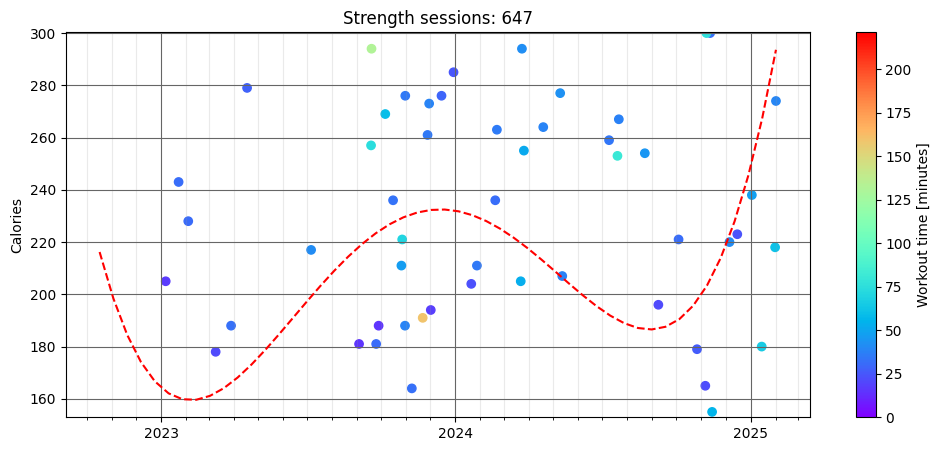

In [18]:
import numpy as np

start_dates = []
moving_times = []
calories = []
for activity in activities:
    if ((activity.name is not None) and ("strength" in activity.name.lower())):
        s = activity.distance
        t = (datetime.combine(date.min, activity.moving_time) - datetime.min).total_seconds()
        start_dates += [activity.start_time]
        moving_times += [t/60]
        calories += [activity.calories]

fig = plt.figure(figsize=(12,5), dpi= 100, facecolor='w', edgecolor='k')
plt.scatter(start_dates, calories, c=moving_times, vmin=0, cmap="rainbow")

x_num = dates.date2num(start_dates)

display(Markdown(str(start_dates)))

trend = np.polyfit(x_num, calories, 4)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "r--")

ax = plt.gca()
plt.grid(visible=True, which='major', color='#666666', linestyle='-')
plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2)
years = plt.matplotlib.dates.YearLocator()
months = plt.matplotlib.dates.MonthLocator()
# yearsFmt = plt.matplotlib.dates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_minor_locator(months)
# ax.xaxis.set_major_formatter(yearsFmt)

plt.title(f"Strength sessions: {len(rows)}")
plt.colorbar(label="Workout time [minutes]")
plt.ylabel("Calories")
#plt.ylim(0, max(moving_times))
plt.show()